# 北京大学毕业生就业版图及其准入门槛的动态变迁（2021-2024）

2400016608 陈湘媛

---

## 0. 数据来源与研究背景
本研究的核心数据集系基于 **北京大学学生就业指导服务中心** 历年发布的官方报告进行整合与结构化处理。具体数据源包括：
* 《北京大学 2021年 - 2024年 毕业生就业质量年度报告》
* 《北京大学 2021年 - 2025年 本科教学质量报告》

##### **数据处理与口径说明**
1. **核心范畴**：原始数据以 **北京大学校本部**（不含医学部）之本科、硕士及博士毕业生为核心观测对象，涵盖毕业规模、落实率、升学流向、单位行业及地域分布等关键指标。
2. **AI 辅助整理**：本数据集由 **Gemini 3** 进行深度检索与自动化整理。在处理过程中，AI 针对原始报告中分散的图表进行了跨年度的横向对齐，并对部分细碎分类进行了战略性取舍，以确保核心趋势的统计显著性。
3. **初次处理状态**：用户当前获取的数据集已是 **第一次数据处理（Initial Processing）** 的结果。我们保留了原始报告中的分类逻辑，并针对未披露或数据缺失的节点统一标注为「--」，以便后续在代码中进行科学的空值化（NaN）处理。
4. **数据侷限性**：受限于原始报告披露维度的差异，部分年份的特定指标（如特定学历的细分行业占比）可能存在断点，分析时应结合样本量进行综合评判。

<br>

##### **研究背景**
&emsp;&emsp;随着高等教育供给侧与市场需求侧的持续调整，毕业生的流向已成为反映宏观经济转型与产业门槛变迁的重要风向标。本分析希望通过整合多维度的就业地理数据与行业结构数据，经过标准化的加权处理，构建起一个多透视的人才流动分析框架，试图揭示隐藏在数字背后的就业逻辑与行业吸引力模型。

---

## 1. 数据导入、处理和解释


#### 1.1 数据和包导入


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

df_grad = pd.read_excel('毕业人数.xlsx')
df_geo = pd.read_excel('单位地域.xlsx')
df_ind = pd.read_excel('单位行业.xlsx')

plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'Heiti SC'] 
plt.rcParams['axes.unicode_minus'] = False 

In [2]:
df_grad

,分类指标,具体项目,21本,22本,23本,24本,21硕,22硕,23硕,24硕,21博,22博,23博,24博,25总体
0,基本规模,毕业人数,--,2981.00,3826,3718,--,5017.00,--,--,--,1800.00,--,--,9826
1,落实率,毕业去向落实率(%),97.2,94.90,94.38,93.81,98.95,98.51,--,--,99.13,98.33,--,--,97.05
2,升学流向,总升学率 (%),71.16,74.30,78.07,84.23,7.23,6.16,--,--,4.37,5.33,--,--,--
3,升学流向,国内升学 (%),52.26,54.11,59.24,65.85,3.97,3.63,--,--,--,0.00,--,--,--
4,升学流向,出国出境 (%),18.9,20.19,18.83,18.38,3.26,2.53,--,--,4.37,5.33,--,--,--
5,就业形式,签约就业 (%),20.81,16.84,--,--,86.23,88.98,--,--,89.92,89.78,--,--,--
6,就业形式,自由职业 (%),4.48,3.39,--,--,2.27,1.69,--,--,2.21,2.00,--,--,--
7,就业形式,创业/其他 (%),0.75,0.37,--,--,3.22,1.68,--,--,2.62,1.22,--,--,--


In [3]:
df_geo

,地域名称,21本%,22本%,23本%,21硕%,22硕%,23硕%,21博%,22博%,23博%,24总人,24总%
0,北京,42.33,42.55,37.42,45.63,48.64,45.19,53.10,52.62,54.59,1965,42.18
1,广东,12.14,11.18,10.69,17.56,15.11,13.93,10.28,8.47,9.79,652,13.99
2,上海,14.06,15.69,11.14,11.94,12.92,13.93,10.14,9.81,6.84,537,11.53
3,浙江,5.59,5.88,8.02,5.22,4.75,6.15,4.08,4.57,3.89,260,5.58
4,四川,2.88,2.94,2.00,2.23,2.95,2.22,2.48,2.22,1.68,167,3.58
5,江苏,3.35,3.14,2.00,2.13,2.01,2.39,3.72,3.23,4.43,142,3.05
6,山东,4.47,2.75,2.90,2.94,1.55,1.75,2.84,2.15,1.95,114,2.45
7,福建,0.80,1.34,1.73,0.73,1.34,--,2.33,2.55,3.62,84,1.80


In [4]:
df_ind

,行业名称,21本,22本,23本,24本,21硕,22硕,23硕,24硕,21博,22博,23博,24博,24总
0,教育,25.56,15.1,16.7,21.91,8.35,7.43,6.32,7.09,47.56,43.21,42.12,43.53,20.50
1,金融业,11.02,12.35,16.6,8.56,22.88,26.26,27.94,28.79,4.3,5.24,4.63,2.83,18.42
2,信息传输、软件和技术服务,26.36,31.96,23.61,22.42,24.76,26.44,22.01,20.04,9.12,12.9,7.65,10.95,17.21
3,公共管理、社会保障,14.86,13.33,16.6,15.62,19.87,17.06,18.15,17.9,9.19,8.27,9.12,8.18,14.47
4,科学研究和技术服务,6.07,3.92,4.45,3.27,4.82,3.99,5.52,4.54,19.69,19.76,16.03,20.09,9.62
5,制造业,1.44,2.75,5.12,4.53,2.53,2.74,3.39,6.42,1.44,5.04,5.03,8.11,6.83
6,租赁和商务服务业,11.02,9.8,11.36,6.3,4.16,6.52,6.32,5.13,0.44,1.14,0.74,0.39,3.65
7,文化、体育和娱乐业,3.04,2.75,1.34,2.02,2.94,2.19,1.68,2.07,1.53,--,--,1.29,1.80
8,军队,--,--,7.13,7.56,--,--,1.46,0.11,--,--,0.87,0.77,0.97
9,卫生和社会工作,--,--,--,--,--,--,--,--,3.43,2.42,1.21,--,0.64


#### 1.2 填充策略

In [5]:
df_grad.replace('--', np.nan, inplace=True)
df_geo.replace('--', 0, inplace=True)
df_ind.replace('--', 0, inplace=True)

/var/folders/yb/87195jd924dbf6bjr1pj0lr80000gn/T/ipykernel_43057/263972522.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_grad.replace('--', np.nan, inplace=True)
/var/folders/yb/87195jd924dbf6bjr1pj0lr80000gn/T/ipykernel_43057/263972522.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_geo.replace('--', 0, inplace=True)
/var/folders/yb/87195jd924dbf6bjr1pj0lr80000gn/T/ipykernel_43057/263972522.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the o

在数据预处理阶段，针对不同性质的数据集采取差异化的填充策略主要是由**数据的统计意义**决定的。

1. `df_grad` (毕业生规模/去向表) 填充为 `np.nan`

&emsp;&emsp;选择将其中的 -- 替换为 np.nan（空值）。这种处理方式旨在保留数据的“真实缺失”状态，因为毕业生人数或落实率属于核心统计指标，任何主观的数值填充都会对年度增长率或平均值的计算产生误导。在后续的折线图分析中，np.nan 会形成视觉上的断点，这能够直观地向读者传达该年度数据未披露的客观事实，避免了因填入零值而导致就业市场出现“断崖式下跌”的错误假象。

2. `df_geo` (地理分布表) 和`df_ind` (行业结构表)填充为 `0`

&emsp;&emsp;地域分布表 df_geo 与行业结构表 df_ind 则统一将 -- 填充为 0。这一决策主要基于数据结构与运算需求的双重考量。从业务逻辑上看，地域或行业分布通常以百分比呈现，当某一年份的特定项显示为 -- 时，通常代表该项的占比极低，不足以进入统计视阈，因此将其视为 0% 具有合理的逻辑支撑。


#### 1.3 结构优化

In [6]:
df_grad = df_grad.drop(df_grad[df_grad['具体项目'] == '毕业人数'].index)
df_grad = df_grad.drop(columns=['25总体'], errors='ignore')
df_grad

,分类指标,具体项目,21本,22本,23本,24本,21硕,22硕,23硕,24硕,21博,22博,23博,24博
1,落实率,毕业去向落实率(%),97.20,94.90,94.38,93.81,98.95,98.51,NaN,NaN,99.13,98.33,NaN,NaN
2,升学流向,总升学率 (%),71.16,74.30,78.07,84.23,7.23,6.16,NaN,NaN,4.37,5.33,NaN,NaN
3,升学流向,国内升学 (%),52.26,54.11,59.24,65.85,3.97,3.63,NaN,NaN,NaN,0.00,NaN,NaN
4,升学流向,出国出境 (%),18.90,20.19,18.83,18.38,3.26,2.53,NaN,NaN,4.37,5.33,NaN,NaN
5,就业形式,签约就业 (%),20.81,16.84,NaN,NaN,86.23,88.98,NaN,NaN,89.92,89.78,NaN,NaN
6,就业形式,自由职业 (%),4.48,3.39,NaN,NaN,2.27,1.69,NaN,NaN,2.21,2.00,NaN,NaN
7,就业形式,创业/其他 (%),0.75,0.37,NaN,NaN,3.22,1.68,NaN,NaN,2.62,1.22,NaN,NaN


&emsp;&emsp;为了确保分析在「量级」与「时间轴」上的统一，本步骤对数据集进行了结构优化。首先，剔除了「毕业人数」行，这是因为该指标属于绝对数量，与表中其他百分比指标（比率）不在同一量纲，移除后可避免可视化时坐标轴被极大值拉平。其次，删除了「25总体」列，由于该列数据来源并非毕业生就业质量年度报告，数据极为不完整，同时在df_ind和df_geo表中都没有25年的数据，因此移除该列有助于后续进行纯粹的纵向趋势对比与矩阵运算。


#### 1.4 指标构建

In [7]:
df_geo['21总%'] = df_geo[['21本%', '21硕%', '21博%']].mean(axis=1).round(2)
df_geo['22总%'] = df_geo[['22本%', '22硕%', '22博%']].mean(axis=1).round(2)
df_geo['23总%'] = df_geo[['23本%', '23硕%', '23博%']].mean(axis=1).round(2)

df_geo


,地域名称,21本%,22本%,23本%,21硕%,22硕%,23硕%,21博%,22博%,23博%,24总人,24总%,21总%,22总%,23总%
0,北京,42.33,42.55,37.42,45.63,48.64,45.19,53.10,52.62,54.59,1965,42.18,47.02,47.94,45.73
1,广东,12.14,11.18,10.69,17.56,15.11,13.93,10.28,8.47,9.79,652,13.99,13.33,11.59,11.47
2,上海,14.06,15.69,11.14,11.94,12.92,13.93,10.14,9.81,6.84,537,11.53,12.05,12.81,10.64
3,浙江,5.59,5.88,8.02,5.22,4.75,6.15,4.08,4.57,3.89,260,5.58,4.96,5.07,6.02
4,四川,2.88,2.94,2.00,2.23,2.95,2.22,2.48,2.22,1.68,167,3.58,2.53,2.70,1.97
5,江苏,3.35,3.14,2.00,2.13,2.01,2.39,3.72,3.23,4.43,142,3.05,3.07,2.79,2.94
6,山东,4.47,2.75,2.90,2.94,1.55,1.75,2.84,2.15,1.95,114,2.45,3.42,2.15,2.20
7,福建,0.80,1.34,1.73,0.73,1.34,0.00,2.33,2.55,3.62,84,1.80,1.29,1.74,1.78


In [8]:
df_ind['21总'] = df_ind[['21本', '21硕', '21博']].mean(axis=1).round(2)
df_ind['22总'] = df_ind[['22本', '22硕', '22博']].mean(axis=1).round(2)
df_ind['23总'] = df_ind[['23本', '23硕', '23博']].mean(axis=1).round(2)

df_ind

,行业名称,21本,22本,23本,24本,21硕,22硕,23硕,24硕,21博,22博,23博,24博,24总,21总,22总,23总
0,教育,25.56,15.10,16.70,21.91,8.35,7.43,6.32,7.09,47.56,43.21,42.12,43.53,20.50,27.16,21.91,21.71
1,金融业,11.02,12.35,16.60,8.56,22.88,26.26,27.94,28.79,4.30,5.24,4.63,2.83,18.42,12.73,14.62,16.39
2,信息传输、软件和技术服务,26.36,31.96,23.61,22.42,24.76,26.44,22.01,20.04,9.12,12.90,7.65,10.95,17.21,20.08,23.77,17.76
3,公共管理、社会保障,14.86,13.33,16.60,15.62,19.87,17.06,18.15,17.90,9.19,8.27,9.12,8.18,14.47,14.64,12.89,14.62
4,科学研究和技术服务,6.07,3.92,4.45,3.27,4.82,3.99,5.52,4.54,19.69,19.76,16.03,20.09,9.62,10.19,9.22,8.67
5,制造业,1.44,2.75,5.12,4.53,2.53,2.74,3.39,6.42,1.44,5.04,5.03,8.11,6.83,1.80,3.51,4.51
6,租赁和商务服务业,11.02,9.80,11.36,6.30,4.16,6.52,6.32,5.13,0.44,1.14,0.74,0.39,3.65,5.21,5.82,6.14
7,文化、体育和娱乐业,3.04,2.75,1.34,2.02,2.94,2.19,1.68,2.07,1.53,0.00,0.00,1.29,1.80,2.50,1.65,1.01
8,军队,0.00,0.00,7.13,7.56,0.00,0.00,1.46,0.11,0.00,0.00,0.87,0.77,0.97,0.00,0.00,3.15
9,卫生和社会工作,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.43,2.42,1.21,0.00,0.64,1.14,0.81,0.40


&emsp;&emsp;为直观捕捉各产业对毕业生的整体吸引力变迁，本研究在预处理阶段构建了“总”指标字段。该指标通过对同年度本科、硕士、博士的分布占比进行均值化处理，旨在消除学历结构细分带来的视觉干扰。

&emsp;&emsp;该字段的构建具有双重分析价值：首先，它为时间序列分析提供了单一变量，使得跨年度的纵向趋势对比（如 2021-2023 年行业热度起伏）更加直观清晰；其次，它为后续核心就业行业的筛选提供了科学的权重基准，确保所提取的头部行业具备全校性的代表性，而非仅反映单一学历阶层的偏好。

In [9]:
weights = np.array([1, 2, 3])
years = ['21', '22', '23', '24']

# 創建一個字典來儲存每年的計算結果
score_data = {'行业名称': df_ind['行业名称']}

for yr in years:
    # 提取當年度的三個學歷列
    cols = [f'{yr}本', f'{yr}硕', f'{yr}博']
    
    # 提取數據矩陣 (處理 NaN 為 0 以便運算)
    matrix = df_ind[cols].fillna(0).values
    
    # 計算加權總和：(占比 * 權重)
    weighted_sum = np.dot(matrix, weights)
    
    # 計算總占比：(本科+碩士+博士)
    total_share = matrix.sum(axis=1)
    
    # 計算最終分數：加權總和 / 總占比
    # 使用 np.divide 處理除以零的情況（若該年該行業無數據則返回 NaN）
    score_data[f'20{yr}年'] = np.divide(weighted_sum, total_share, 
                                       out=np.zeros_like(weighted_sum), 
                                       where=total_share!=0)

# 轉換為 DataFrame 並排序
df_scores = pd.DataFrame(score_data)
# 替換掉 0 值為 NaN（代表無數據）
df_scores.replace(0, np.nan, inplace=True)
# 按 2024 年門檻從高到低排序
df_scores = df_scores.sort_values(by='2024年', ascending=False).reset_index(drop=True)

df_scores.round(3)

,行业名称,2021年,2022年,2023年,2024年
0,科学研究和技术服务,2.445,2.572,2.445,2.603
1,教育,2.270,2.428,2.390,2.298
2,制造业,2.000,2.217,1.993,2.188
3,其他,1.778,1.653,1.876,2.146
4,文化、体育和娱乐业,1.799,1.443,1.556,1.864
5,金融业,1.824,1.838,1.757,1.857
6,公共管理、社会保障,1.871,1.869,1.829,1.822
7,信息传输、软件和技术服务,1.714,1.733,1.700,1.785
8,租赁和商务服务业,1.323,1.504,1.423,1.500
9,军队,NaN,NaN,1.338,1.195


&emsp;&emsp;在分析毕业生去向时，仅看各学历层次的占比往往显得过于碎片化。例如，某个行业吸引了 30% 的硕士和 10% 的博士，而另一个行业吸引了 50% 的本科生，我们很难直接判断哪一个行业的人才准入门槛更高。构建这张表的指标核心，就是为了将这些分散的百分比转化为一个可量化、可对比的「门槛分数」。

&emsp;&emsp;透过为本科、硕士、博士分别赋予 1、2、3 的权重，实际上是在计算一个「学历加权平均值」。这个分数在 1 到 3 之间波动：分数越接近 3，代表该行业吸纳的人才越集中于高学历（硕博）群体，准入门槛越陡峭；分数越接近 1，则代表该行业更偏好吸纳本科生，人才结构相对扁平。这种转化让复杂的学历构成变成了一个直观的行业竞争力坐标。

&emsp;&emsp;从数据结果来看，这张表揭示了清晰的产业分层。例如，「科学研究和技术服务」的分数始终维持在 2.4 以上并在 2024 年攀升至 2.6，直观地反映了科研岗位对高精尖人才的高度依赖；而「租赁和商务服务业」的分数则稳定在 1.5 左右，显示其对本科层次人才有着更广泛的接纳度。这种对比为我们观察产业升级、学历溢价以及人才供需的动态平衡提供了最直接的数据支撑。

#### 1.5 数据检视

In [10]:
df_ind.describe()

,21本,22本,23本,24本,21硕,22硕,23硕,24硕,21博,22博,23博,24博,24总,21总,22总,23总
count,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000
mean,9.962727,8.716364,9.477273,8.494545,9.090000,8.855455,8.743636,8.570909,9.221818,8.968182,8.006364,8.926364,8.559091,9.423636,8.847273,8.741818
std,9.341610,9.411885,7.930517,7.999578,9.173152,9.827932,9.443710,9.435658,13.925335,12.915563,12.319038,12.996911,7.850993,8.657796,8.415788,7.589836
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.040000,0.000000,0.000000,0.400000
25%,2.240000,2.750000,2.895000,2.645000,2.735000,2.465000,2.535000,2.130000,1.485000,0.905000,0.805000,1.030000,1.385000,2.150000,2.385000,2.475000
50%,10.220000,3.920000,7.130000,6.300000,4.820000,4.780000,5.520000,5.130000,4.300000,5.040000,4.630000,2.830000,6.830000,8.210000,5.820000,6.140000
75%,12.940000,12.840000,16.600000,12.090000,14.775000,12.245000,12.235000,12.495000,9.155000,10.585000,8.385000,9.565000,15.840000,13.685000,13.755000,15.505000
max,26.360000,31.960000,23.610000,22.420000,24.760000,26.440000,27.940000,28.790000,47.560000,43.210000,42.120000,43.530000,20.500000,27.160000,23.770000,21.710000


&emsp;&emsp;通过对 df_ind 的描述性统计分析可见，各项均值普遍高于中位数，呈现典型的右偏分布特征。这表明北京大学毕业生的去向具有显著的头部效应，少数热门核心行业吸纳了绝大部分人才。标准差对比显示，博士群体的择业极差（std）远高于本科生，反映出高学历人才的流向更具专业极化性，而本科生在行业分布上则相对平均且多元。

&emsp;&emsp;从纵向维度观察，近四年核心行业吸纳占比的最大值呈小幅波动回落态势，暗示人才流动结构正从过度集中向均衡分布微调。此外，25%分位数与均值的平稳衔接，验证了预处理阶段构建的“总”指标具备良好的统计稳健性，能够为后续的趋势判定与权重筛选提供可靠的实证支撑。

In [11]:
df_geo.describe()

,21本%,22本%,23本%,21硕%,22硕%,23硕%,21博%,22博%,23博%,24总人,24总%,21总%,22总%,23总%
count,8.000000,8.000000,8.00000,8.00000,8.000000,8.000000,8.000000,8.000000,8.00000,8.000000,8.000000,8.00000,8.000000,8.00000
mean,10.702500,10.683750,9.48750,11.04750,11.158750,10.695000,11.121250,10.702500,10.84875,490.125000,10.520000,10.95875,10.848750,10.34375
std,13.585338,13.789057,11.96575,15.13072,16.055483,14.960363,17.274176,17.187473,17.87105,631.169309,13.548579,15.24470,15.600064,14.81713
min,0.800000,1.340000,1.73000,0.73000,1.340000,0.000000,2.330000,2.150000,1.68000,84.000000,1.800000,1.29000,1.740000,1.78000
25%,3.232500,2.892500,2.00000,2.20500,1.895000,2.102500,2.750000,2.467500,3.20250,135.000000,2.900000,2.93500,2.562500,2.14250
50%,5.030000,4.510000,5.46000,4.08000,3.850000,4.270000,3.900000,3.900000,4.16000,213.500000,4.580000,4.19000,3.930000,4.48000
75%,12.620000,12.307500,10.80250,13.34500,13.467500,13.930000,10.175000,8.805000,7.57750,565.750000,12.145000,12.37000,11.895000,10.84750
max,42.330000,42.550000,37.42000,45.63000,48.640000,45.190000,53.100000,52.620000,54.59000,1965.000000,42.180000,47.02000,47.940000,45.73000


&emsp;&emsp;地域分布则呈现出极强空间集聚感。数据显示，虽然平均每个省份的吸纳占比在 10% 左右，但北京、上海、广东等核心城市的最大占比却超过了 40%，呈现出明显的长尾分布。

&emsp;&emsp;这种地域引力的差异在学历上体现得尤为明显，学历越高，向资源高地集中的倾向越强。博士生在一线城市的集中度远超本科生，这与顶尖科研资源的空间分布高度契合。从 2021 到 2024 年，核心城市对优质人才的虹吸效应依然是当前就业市场的主旋律。

In [12]:
df_grad.describe()

,21本,22本,23本,24本,21硕,22硕,23硕,24硕,21博,22博,23博,24博
count,7.000000,7.000000,4.000000,4.000000,7.000000,7.000000,0.0,0.0,6.00000,7.000000,0.0,0.0
mean,37.937143,37.728571,62.630000,65.567500,29.304286,29.025714,NaN,NaN,33.77000,28.855714,NaN,NaN
std,36.466890,36.952959,32.539147,33.529428,43.416030,44.323466,NaN,NaN,47.15894,44.652319,NaN,NaN
min,0.750000,0.370000,18.830000,18.380000,2.270000,1.680000,NaN,NaN,2.21000,0.000000,NaN,NaN
25%,11.690000,10.115000,49.137500,53.982500,3.240000,2.110000,NaN,NaN,3.05750,1.610000,NaN,NaN
50%,20.810000,20.190000,68.655000,75.040000,3.970000,3.630000,NaN,NaN,4.37000,5.330000,NaN,NaN
75%,61.710000,64.205000,82.147500,86.625000,46.730000,47.570000,NaN,NaN,68.53250,47.555000,NaN,NaN
max,97.200000,94.900000,94.380000,93.810000,98.950000,98.510000,NaN,NaN,99.13000,98.330000,NaN,NaN


&emsp;&emsp;在清理掉人数总量后，现在的表格展示的是纯粹的百分比结构。从数据来看，最突出的特点是“稳”：各年度的就业落实率（Max）始终保持在 93% 到 99% 的超高水平，反映出毕业生极强的市场竞争力。不过，不同学历的选择差异很大。本科生的平均值在近两年明显抬升，这主要是因为绝大多数本科生都选择了继续深造；而硕士和博士的数据波动更大，说明他们的职业选择更受专业影响，分布相对两极分化。

&emsp;&emsp;另外，表格中出现的空值（NaN）也印证了原始报告在不同年份的统计口径并不完全一致，23及24年的北京大学并没有在毕业生就业质量年度报告中，对除了本科以外的毕业生数据进行公开。虽然存在这些“数据断层”，但从已有的趋势来看，本科生升学比例的持续走高是近年来最显著的变化。

---

## 2. 数据可视化
### 2.1 毕业生去向数据可视化

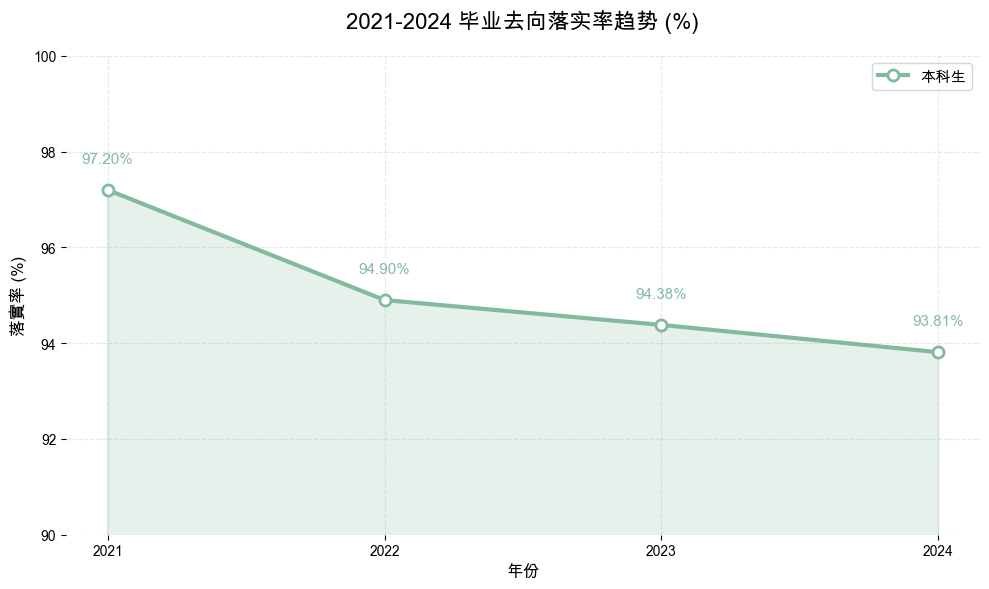

In [13]:
plt.figure(figsize=(10, 6))

target_row = df_grad[df_grad['具体项目'] == '毕业去向落实率(%)']
plot_values = target_row[['21本', '22本', '23本', '24本']].values.flatten()
years = ['2021', '2022', '2023', '2024']

# 繪製折線圖
plt.plot(years, plot_values, 
         marker='o', 
         markersize=8, 
         linewidth=3, 
         color='#83ba9e', 
         label='本科生',
         markerfacecolor='white',
         markeredgewidth=2,
         zorder=3) # 確保折線在填充層上方

# 填充折線下的面積 
plt.fill_between(years, plot_values, 
                 color='#83ba9e', 
                 alpha=0.2,   # 設置透明度，使視覺效果更輕盈
                 zorder=2)

#在數據點上添加數值標註
for x, y in zip(years, plot_values):
    plt.text(x, y + 0.5, f'{y:.2f}%', ha='center', va='bottom', 
             fontsize=11, fontweight='bold', color='#83ba9e')

# 設置標題與標籤
plt.title('2021-2024 毕业去向落实率趋势 (%)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('年份', fontsize=12)
plt.ylabel('落實率 (%)', fontsize=12)

# 美化坐標軸範圍
plt.ylim(90, 100) 
sns.despine(left=True, bottom=True) 

# 顯示圖例與圖表
plt.grid(visible=True, axis='both', linestyle='--', alpha=0.3, zorder=1)
plt.legend(frameon=True, loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

&emsp;&emsp;由以上毕业去向落实率趋势图可以看到，虽然落实率在过去四年中始终维持在 93% 以上的高位，但整体呈现出一种缓慢下滑的态势。2021 年时，本科生的落实率还处于 97.20% 的极高水平，随后在 2022 年出现了较明显的下降，跌破 95% 关口至 94.90%，并在此后两年继续微幅走低，到 2024 年降至 93.81%。

&emsp;&emsp;从整体去向落实率的微降中，我们可以窥见北京大学毕业生“精英光环”下的现实压力。2021年到2024年，这约3.4个百分点的降幅，虽然在统计学上看似轻微，但在现实中却折射出就业市场的深刻变革。即使是国内顶尖学府的学子，也开始感受到“包分配”式顺遂时代的远去，转而进入了一个更加审慎、竞争更激烈的筛选周期。

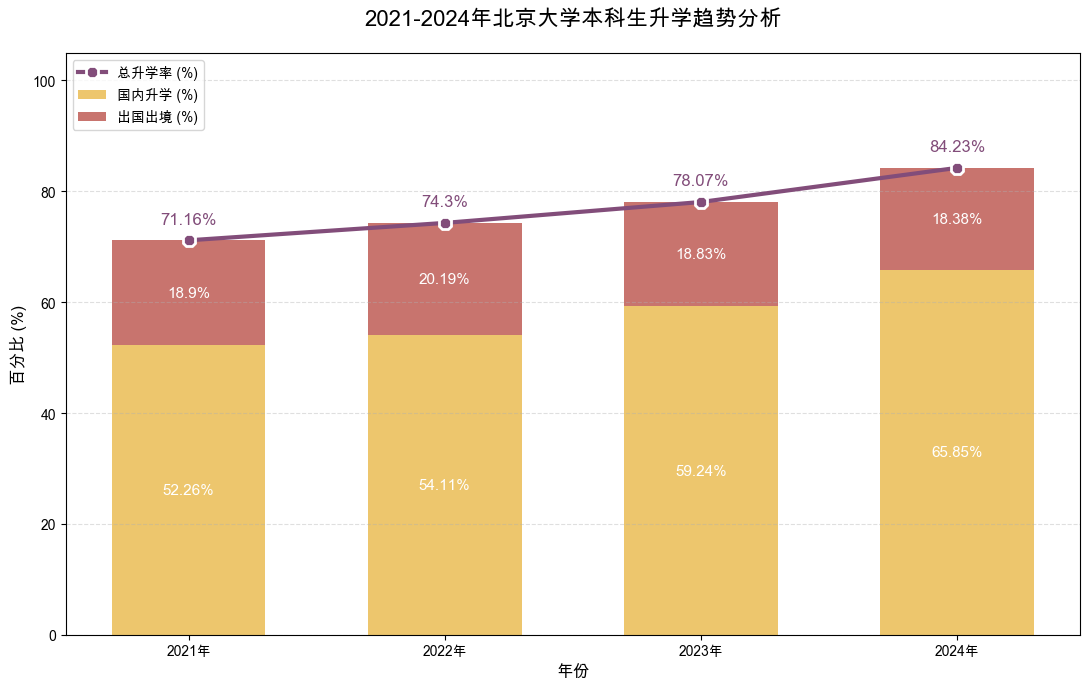

In [14]:
def clean_val(val):
    if isinstance(val, str):
        val = val.replace('%', '').replace('--', '0').strip()
    try: return float(val)
    except: return 0.0

# 2. 提取 2021-2024 本科生數據
years = ['2021年', '2022年', '2023年', '2024年']
cols = ['21本', '22本', '23本', '24本']

domestic = [clean_val(df_grad[df_grad['具体项目'] == '国内升学 (%)'][col].values[0]) for col in cols]
abroad = [clean_val(df_grad[df_grad['具体项目'] == '出国出境 (%)'][col].values[0]) for col in cols]
total = [clean_val(df_grad[df_grad['具体项目'] == '总升学率 (%)'][col].values[0]) for col in cols]

# 3. 繪圖與配色優化
plt.figure(figsize=(11, 7), dpi=100)

# 使用專業商務配色
color_domestic = '#EBC05D' 
color_abroad = '#C2655E'
color_line = '#824D7A'

# 繪製堆疊柱狀圖
plt.bar(years, domestic, label='国内升学 (%)', color=color_domestic, alpha=0.9, width=0.6)
plt.bar(years, abroad, bottom=domestic, label='出国出境 (%)', color=color_abroad, alpha=0.9, width=0.6)

# 繪製總升學率趨勢線
plt.plot(years, total, marker='8', color=color_line, label='总升学率 (%)', 
         linewidth=3, markersize=10, markeredgecolor='white', markeredgewidth=2)

# 4. 圖表細節優化
plt.title('2021-2024年北京大学本科生升学趋势分析', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('百分比 (%)', fontsize=12)
plt.xlabel('年份', fontsize=12)
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 添加數值標註
for i in range(len(years)):
    # 國內數值
    plt.text(i, domestic[i]/2, f'{domestic[i]}%', ha='center', va='center', color='white', fontweight='bold', fontsize=11)
    # 國外數值
    plt.text(i, domestic[i] + abroad[i]/2, f'{abroad[i]}%', ha='center', va='center', color='white', fontweight='bold', fontsize=11)
    # 總量標註 (頂部)
    plt.text(i, total[i] + 3, f'{total[i]}%', ha='center', color=color_line, fontweight='bold', fontsize=12)

plt.legend(loc='upper left', frameon=True, fontsize=10)
plt.tight_layout()

plt.show()

&emsp;&emsp;由2021-2024年北京大学本科生升学趋势分析圖，我们会发现落实率小幅下降的背后，实际上是毕业生选择路径的结构性调整。北京大学本科生的总升学率在这四年里表现出极其强劲的增长势头，从 2021 年的 71.16% 一路攀升至 2024 年的 84.23%。这意味着绝大多数北大本科生在毕业后并未直接进入就业市场，而是选择了继续深造。

&emsp;&emsp;深入观察升学的构成可以发现，国内升学是推动这一增长的核心引擎。国内升学比例从 52.26% 连年上涨，到 2024 年已经高达 65.85%，显示出学生们对国内优质高等教育资源以及深造确定性的高度青睐。相比之下，出国出境深造的比例则显得相对平稳甚至略有波动。在 2022 年达到 20.19% 的小高峰后，近两年略微回落并稳定在 18% 左右。


#### &emsp;&emsp; 综合来看，这两张图表勾勒出一个清晰的画像，在当前的社会经济背景下，北京大学本科生群体表现出明显的“慢就业”或“高深造”倾向。随着学习成本相对上比国外升学更低的国内升学途径成为绝对主流，毕业生们正通过延长学习年限、提升学术资历来应对未来的职业挑战，这种“学术深造替代直接就业”的趋势在四年间变得愈发显著。

### 2.2 毕业生就业地域分布

<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/var/folders/yb/87195jd924dbf6bjr1pj0lr80000gn/T/ipykernel_43057/1578689726.py:10: SyntaxWarning: invalid escape sequence '\d'
  df_melted['年份_idx'] = df_melted['年份'].str.extract('(\d+)').astype(int)


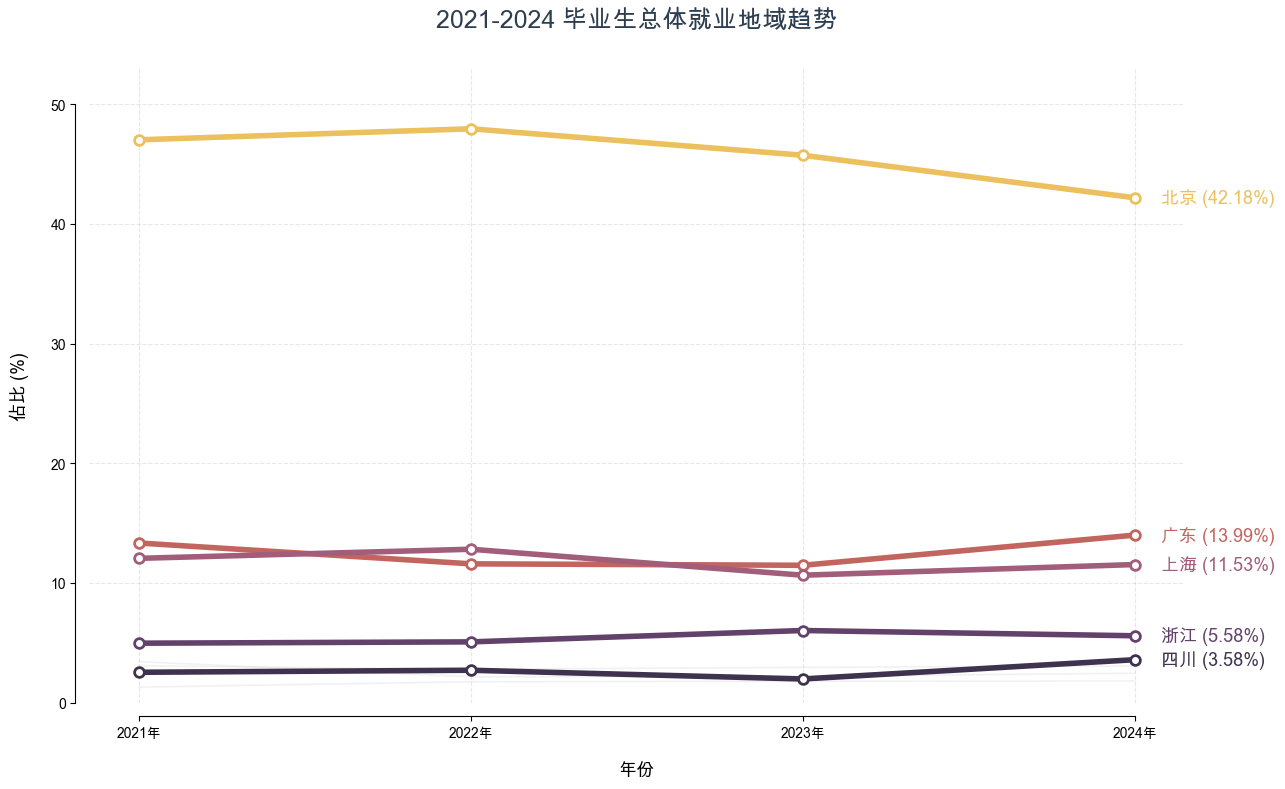

In [15]:
# --- 2. 獲取前五名地區 ---
top_5_df = df_geo.nlargest(5, '24总%')
top_5_regions = top_5_df['地域名称'].tolist()

# --- 3. 數據長表化 ---
df_melted = df_geo.melt(id_vars='地域名称', 
                        value_vars=['21总%', '22总%', '23总%', '24总%'], 
                        var_name='年份', 
                        value_name='百分比')
df_melted['年份_idx'] = df_melted['年份'].str.extract('(\d+)').astype(int)

# --- 4. 定義圖片同款配色表 (自定義高級配色) ---
custom_colors = [
    '#EBC05D', 
    '#C2655E', 
    '#A15D7A', 
    '#62426B', 
    '#3E324F'  
]
region_colors = {region: custom_colors[i] for i, region in enumerate(top_5_regions)}

# --- 5. 繪圖畫布 ---
fig, ax = plt.subplots(figsize=(13, 8))

label_data = []

# --- 6. 循環繪製折線 ---
for region in df_geo['地域名称'].unique():
    subset = df_melted[df_melted['地域名称'] == region].dropna().sort_values('年份_idx')
    if subset.empty: continue
    
    if region in top_5_regions:
        # 【前五名地區】：圖片同款色、加粗、置於頂層
        color = region_colors[region]
        line, = ax.plot(subset['年份_idx'], subset['百分比'], 
                        marker='o', markersize=7,
                        linewidth=4, color=color, zorder=10,
                        markerfacecolor='white', markeredgewidth=2)
        
        # 記錄末端標籤數據
        last_point = subset.iloc[-1]
        label_data.append({
            'name': region,
            'x': last_point['年份_idx'],
            'y': last_point['百分比'],
            'color': color
        })
    else:
        # 【其他地區】：淺灰色、細線、置於底層 (Spaghetti Chart 效果)
        ax.plot(subset['年份_idx'], subset['百分比'], 
                color='#D3D3D3', linewidth=1.2, alpha=0.3, zorder=1)

# --- 7. 標籤垂直防重疊算法 (Nudging) ---
label_data.sort(key=lambda x: x['y'])
min_dist = 2.0  # 稍微加大間距
adjusted_y = [item['y'] for item in label_data]

for i in range(1, len(adjusted_y)):
    if adjusted_y[i] - adjusted_y[i-1] < min_dist:
        adjusted_y[i] = adjusted_y[i-1] + min_dist

# --- 8. 繪製末端標籤 ---
for i, item in enumerate(label_data):
    ax.text(item['x'] + 0.08, adjusted_y[i], 
            f"{item['name']} ({item['y']:.2f}%)", 
            va='center', ha='left', fontsize=13, 
            color=item['color'], fontweight='bold')

# --- 9. 圖表裝飾 (視覺統一化) ---
ax.set_title('2021-2024 毕业生总体就业地域趋势', fontsize=18, pad=30, fontweight='bold', color='#2c3e50')
ax.set_xticks([21, 22, 23, 24])
ax.set_xticklabels(['2021年', '2022年', '2023年', '2024年'], fontsize=12)
ax.set_xlabel('年份', fontsize=13, labelpad=15)
ax.set_ylabel('佔比 (%)', fontsize=13, labelpad=15)

# 設置 Y 軸範圍留白，讓圖表更透氣
current_ylim = ax.get_ylim()
ax.set_ylim(0, max(df_melted['百分比']) + 5)

# 移除上方和右側邊框，增加專業感
sns.despine(offset=10, trim=True)
plt.subplots_adjust(right=0.8)

plt.grid(visible=True, axis='both', linestyle='--', alpha=0.3, zorder=1)
plt.tight_layout()
plt.show()


&emsp;&emsp;从上图，北京大学毕业生的去向呈现出极强的地缘粘性。北京作为学校所在地，其吸引力虽然从2021年的47%左右小幅下滑至 2024年的42.18%，但依然稳居绝对统治地位。这种「近水楼台」的现象，不仅是因为北京集聚了全国最优质的党政机关、科研院所及企业总部，更在于北京大学作为首都高等教育的旗帜，其人才培养与北京的高端产业结构有着天然的供需匹配。

&emsp;&emsp;在这一核心区之外，广东与上海构成了稳固的第二梯队。这两地占比在 10% - 15%$之间波动，反映出珠三角与长三角两大经济引擎对北大学子的持续吸纳力。相比之下，浙江、四川等省份虽然在个位数区间内艰难攀升，但仍难撼动一线城市的地位。这勾勒出一种典型的头部集聚模型：超过70%的北大学子最终流向了京沪粤这三个最具竞争力的增长极，而北京则是其中雷打不动的定海神针。


#### &emsp;&emsp;从这两张图中，我们可以总结出两个核心信息。首先，北京作为母校所在地的「主场优势」极强且稳固。尽管 2024 年的数据因统计口径调整略有缺位，但往年数据清晰显示，超过 40% 的毕业生首选留京。这不仅是因为地缘便利，更在于北京集聚了最顶尖的党政机关和科研总部，与北大的人才培养体系达成了深度的供需契合。

#### &emsp;&emsp;其次，地域流向与学历层级之间存在精准的「错位匹配」。在北大学子流向全国的过程中，不同省份表现出截然不同的吸纳逻辑。江苏和福建由于接收总量较少，主要通过高端引进政策精准锁定博士群体，导致其博士占比异常高（江苏超 50%，福建近 70%）。而浙江则凭借活跃的民营经济，在北大的稀缺本科生源中抢占了近 44.4% 的份额。

#### &emsp;&emsp;综合来看，北大学子正以北京为核心，根据自身学历杠杆进行战略分布：高学历者流向苏闽等地的科研与体制尖端，而本科生则在浙江等产业前沿寻求突破。这种「少而精」的分布规律，反映了顶尖人才在空间布局上的优化配置。


In [16]:
df_geo_norm = df_geo.copy()
years = ['21', '22', '23', '24']
degrees = {'本': '本科', '硕': '硕士', '博': '博士'}

for yr in years:
    # 提取当年三个学历的列名
    cols = [f'{yr}本%', f'{yr}硕%', f'{yr}博%']
    # 检查列是否存在于数据中
    valid_cols = [c for c in cols if c in df_geo_norm.columns]
    if len(valid_cols) == 3:
        # 计算每一行的总和
        row_sum = df_geo_norm[valid_cols].sum(axis=1)
        # 执行归一化：(值 / 总和) * 100
        # 处理后，每个城市在该年份的三个学历占比相加等于 100%
        df_geo_norm[valid_cols] = df_geo_norm[valid_cols].div(row_sum, axis=0) * 100

# 保存标准化后的数据
df_geo_norm.to_csv('normalized_geo_data.csv', index=False)

# 2. 转换为长表以便进行动态可视化
rows = []
for _, row in df_geo_norm.iterrows():
    for yr in years:
        for deg_code, deg_name in degrees.items():
            col_name = f"{yr}{deg_code}%"
            if col_name in df_geo_norm.columns:
                rows.append({
                    '地域名称': row['地域名称'],
                    '年份': f"20{yr}年",
                    '学历层次': deg_name,
                    '占比(%)': row[col_name]
                })

df_long_geo = pd.DataFrame(rows)

# 3. 绘制动态标准化堆叠图
geo_colors = {"本科": '#EBC05D', "硕士": '#A15D7A', "博士": '#3E324F'}
fig = px.bar(
    df_long_geo, 
    x="地域名称", 
    y="占比(%)", 
    color="学历层次",
    animation_frame="年份", 
    title="2021-2023 各地区人才吸纳结构标准化动态对比",
    color_discrete_map=geo_colors,
    barmode='stack',
    category_orders={"学历层次": ["本科", "硕士", "博士"]},
    range_y=[0, 100],
    text_auto='.1f'
)

fig.update_layout(width=900, height=600, xaxis_title="省市", yaxis_title="内部学历构成占比 (%)")
fig.show()

&emsp;&emsp;结合北京大学本科生规模本就有限，以及江苏、福建两地接收毕业生总量较少的现实背景，这组动态图表揭示了一种极高浓度的人才配置逻辑。由于北大每年本科毕业生仅三千人左右，且其中逾八成选择升学，真正进入就业市场的本科生极具稀缺性。在这种供给规模下，江苏与福建的学历结构呈现出一种“非顶尖不取”的态势：江苏在 2023 年高达 50.2% 的博士占比，并非依靠规模取胜，而是通过极少数但极高端的岗位实现了对北大顶尖科研力量的精准吸纳。福建更是如此，其博士占比在三年间从60.4% 波动上升至 67.7% ，这种惊人的比例与其说是人才市场的自然分布，不如说是两省针对北大博士群体开展的专项人才引进政策（如选调生或高水平科研引进）所产生的直接结果。

&emsp;&emsp;在这些样本量相对较小的省份，数据对特定政策的敏感度极高，每一个百分点的波动往往代表着十几位甚至几位博士的流向抉择。相比之下，北京作为北大毕业生的首选地，尽管本科生源同样稀缺，但其72.7% 的硕博占比是在更大的人才基数上形成的，展现了首都对高端人才的全方位消化能力。而浙江之所以能维持 44.4%的本科占比，则体现了在有限的北大本科就业人口中，浙江通过其活跃的民营经济和互联网产业，成功抢占了这部分稀缺资源。这种“少而精”的分布规律表明，北大学子在这些省份的着陆点并非泛泛的职场，而是被高度锁定在了特定行业和高端平台上。

&emsp;&emsp;同时，由于北京大学2024年的报告并没有分别展示各个学籍的毕业生的就业单短地区，导致 2024 年数据是缺位的。


### 2.3 毕业生就业行业分布

In [17]:
# 設置 6 色自定義配色方案 (從淺到深)
custom_colors = [
    '#EBC05D', # 1. 芥末黃
    '#C2655E', # 2. 煙燻玫瑰紅
    '#A15D7A', # 3. 桑葚紫紅
    '#824D7A', # 4. 暗葡萄紫
    '#62426B', # 5. 深紫羅蘭
    '#3E324F'  # 6. 深褐紫
]

top_5_industries = df_ind.nlargest(5, '24总')['行业名称'].tolist()
df_top5 = df_ind[df_ind['行业名称'].isin(top_5_industries)].copy()

rows = []
years = ['21', '22', '23', '24']
degrees = ['本', '硕', '博']

for _, row in df_top5.iterrows():
    for yr in years:
        for deg in degrees:
            col_name = f"{yr}{deg}"
            if col_name in df_top5.columns:
                val = pd.to_numeric(row[col_name])
                rows.append({
                    '行业名称': row['行业名称'],
                    '年份': f"20{yr}年",
                    '学历层次': f"{deg}科" if deg == '本' else (f"{deg}士"),
                    '占比(%)': val if not np.isnan(val) else 0
                })

df_long = pd.DataFrame(rows)


fig = px.density_heatmap(
    df_long, 
    x="学历层次", 
    y="行业名称", 
    z="占比(%)",
    animation_frame="年份", 
    color_continuous_scale=custom_colors, # 應用 6 色方案
    labels={'占比(%)': '就业占比'},
    title="2021-2024 前五大行业人才吸纳结构动态变迁", # 簡體中文標題
    range_color=[0, 50], # 固定比例尺方便對比
    text_auto='.1f',
    category_orders={"学历层次": ["本科", "硕士", "博士"]} # 確保順序
)


fig.update_layout(
    width=800,
    height=600,
    xaxis_title="学历层次",
    yaxis_title="行业名称",
    font=dict(size=12) 
)

fig.show()

&emsp;&emsp;以上动态图展示了 2021 年到 2024 年间，北京大学毕业生在五大行业中的学历分布演变。通过观察热力颜色的深浅波动，我们可以直观地看到不同行业对人才要求的差异以及这四年间的细微调整。

&emsp;&emsp;教育行业始终是博士生比例最高的地方。从 2021 年的 47.6% 到 2024 年的 43.5%，博士群体始终占据该行业的近半数份额。这说明北大学子进入教育领域时，绝大多数都进入了高等院校或高水平研究机构，学历门槛非常高而且表现得十分稳定。与此同时，科学研究和技术服务业也呈现出类似的特征，其博士占比在 2024 年回升到了 20.1%，再次证明了科研岗位对顶尖学术训练的刚性需求。

&emsp;&emsp;在金融以及信息技术这两个领域，硕士群体展现出了中流砥柱的作用。金融业的硕士吸纳占比从 22.9% 稳步攀升到了 28.8%，成为该行业颜色最深、最核心的组成部分。而信息传输与软件服务业在经历了几年的波动后，虽然本科生占比仍保持在 22.4% 的水平，但硕士的占比也紧随其后。这种变化预示着在互联网和高端金融领域，硕士学历正在成为更有竞争力的通行证。

&emsp;&emsp;公共管理与社会保障领域的分布则显得最为平稳，硕士占比连年保持在 17% 到 19% 之间，显示出公职体系在人才吸纳上的计划性和结构性特征。综合来看，这四年间的博士生就业主要分布在教育和科研领域，硕士生在金融和公职领域发挥着越来越大的作用，而本科生则在信息技术等实务领域寻求发展。随着北大学子升学率逐年走高，这种按学历水平划分职业坐标的趋势正变得越来越明显。

In [18]:
top_industries = df_ind.nlargest(5, '24总')['行业名称'].tolist()
df_top = df_ind[df_ind['行业名称'].isin(top_industries)].reset_index(drop=True)

# 3. 建立節點標籤與顏色
# 左側節點: 本科(0), 硕士(1), 博士(2) | 右側節點: 各行業 (3, 4, 5, 6, 7)
degrees = ["本科", "硕士", "博士"]
industry_labels = df_top['行业名称'].tolist()
label = degrees + industry_labels

df_plot = df_ind.copy()
all_industries = df_plot['行业名称'].unique()
colors_palette = px.colors.qualitative.Prism 
color_map = {ind: colors_palette[i % len(colors_palette)] for i, ind in enumerate(all_industries)}

color_nodes = ['#83ba9e', '#194a55', '#f59129'] + [color_map[ind] for ind in industry_labels]

# 4. 定義數據提取函數 (自動化核心)
def get_sankey_data(year):
    sources = []
    targets = []
    values = []
    
    # 遍歷學歷與行業的組合
    for i, deg in enumerate(['本', '硕', '博']):
        col_name = f"{year}{deg}"
        for j, ind in enumerate(industry_labels):
            val = df_top.loc[j, col_name]
            # 轉換數據類型，處理 '--' 或異常值
            val = pd.to_numeric(val, errors='coerce') if val != '--' else 0
            
            sources.append(i)         # 0, 1, 2 (學歷)
            targets.append(j + 3)    # 3, 4, 5, 6, 7 (行業)
            values.append(val if not np.isnan(val) else 0)
            
    link_colors = ['rgba(131, 186, 158, 0.4)' if s==0 else 
                   'rgba(25, 74, 85, 0.4)' if s==1 else 
                   'rgba(245, 145, 41, 0.4)' for s in sources]
    
    return sources, targets, values, link_colors

# 5. 創建桑基圖對象的構造函數
def make_sankey_frame(year):
    s, t, v, c = get_sankey_data(year)
    return go.Sankey(
        node=dict(
            pad=15, 
            thickness=20, 
            line=dict(color="white", width=0.5), 
            label=label, 
            color=color_nodes
        ),
        link=dict(
            source=s, 
            target=t, 
            value=v, 
            color=c
        )
    )

# 6. 初始化圖表 (2021年)
fig = go.Figure(data=[make_sankey_frame('21')])

# 7. 自動化生成動畫幀 (2021-2024)
years = ['21', '22', '23', '24']
fig.frames = [go.Frame(data=[make_sankey_frame(yr)], name=f"20{yr}年") for yr in years]

# 8. 配置佈局與播放軸 (標題改為簡體中文)
fig.update_layout(
    title_text="2021-2024 毕业生学历与前五大行业行业去向动态变迁",
    font=dict(family="Arial Unicode MS", size=12),
    width=1000, 
    height=700,
    updatemenus=[{
        "buttons": [
            {"args": [None, {"frame": {"duration": 1000, "redraw": True}, "fromcurrent": True}],
             "label": "▶ 播放", "method": "animate"},
            {"args": [[None], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
             "label": "■ 停止", "method": "animate"}
        ],
        "direction": "left", "pad": {"r": 10, "t": 87}, "showactive": False, "type": "buttons", "x": 0.1, "xanchor": "right", "y": 0, "yanchor": "top"
    }],
    sliders=[{
        "active": 0, 
        "yanchor": "top", 
        "xanchor": "left",
        "currentvalue": {"font": {"size": 20}, "prefix": "统计年份: ", "visible": True, "xanchor": "right"},
        "transition": {"duration": 500, "easing": "cubic-in-out"},
        "pad": {"b": 10, "t": 50}, "len": 0.9, "x": 0.1, "y": 0,
        "steps": [
            {"args": [[f"20{yr}年"], {"frame": {"duration": 500, "redraw": True}, "mode": "immediate"}], 
             "label": f"20{yr}年", "method": "animate"} for yr in years
        ]
    }]
)

# 9. 顯示圖表
fig.show()

&emsp;&emsp;这组桑基图直观地展示了毕业生学历背景与最终行业去向之间的流动关系，通过线条的粗细，可以清晰地感受到不同学历群体在就业市场中的分流趋势。

&emsp;&emsp;在整体流向中，博士生群体展现出极强的去向集中度。绝大部分博士生像一股粗壮的洪流直接汇入了教育行业，这也印证了高等院校和科研机构依然是高学历人才最核心的吸纳地。相比之下，本科生和硕士生的去向则显得更加分散且多元。本科生在信息技术以及教育领域的分布相对均衡，而硕士生则在金融业和公共管理领域占据了显著的份额。随着年份的推进，我们可以发现硕士生流向金融行业的线条在视觉上保持了较强的韧性，而本科生流向信息技术行业的比例则经历了一定的波动调整。

&emsp;&emsp;将这张桑基图与之前的热力图进行对比，两者在呈现逻辑上有着本质的区别。热力图侧重于横向的占比分析，它像是一张截面扫描，告诉我们在每一个特定行业内部，不同学历人才的分布密集程度，让我们一眼看出哪个行业更偏好哪种学历。而这张桑基图则侧重于纵向的流动过程，它更像是一条动态的水流，追踪每一类学历群体究竟流向了何方。桑基图强调的是来源与去向的因果联系，它能让我们看到某种学历群体在不同行业间的分配比例。

&emsp;&emsp;制作这两张图的意义在于互补地构建出完整的就业景观。热力图解决了行业招什么人的问题，帮助我们理解不同行业的准入门槛和学历性格。而桑基图解决了学生去哪里的问题，让我们能从人才供给的角度，观察北大学子如何根据自身的学历杠杆在社会各个关键领域进行战略分布。结合这两张图，我们不仅能看到教育行业是博士生的避风港，也能看到金融业如何一步步成为硕士生的主要舞台。这种全方位的透视，对于理解顶尖高校人才的社会流动规律具有重要的参考价值。


In [19]:
df_plot = df_ind.copy()
years = ['21', '22', '23', '24']
# 固定學歷顏色
degree_colors = ['#83ba9e', '#194a55', '#f59129'] # 本、碩、博

# 建立全局行業顏色映射 (確保所有圖表顏色一致)
all_industries = df_plot['行业名称'].unique()
colors_palette = px.colors.qualitative.Prism 
color_map = {ind: colors_palette[i % len(colors_palette)] for i, ind in enumerate(all_industries)}

# --- 2. 定義矩形樹圖 (Treemap) 構造函數 ---
def make_frame_data(year_str):
    col = f"{year_str}总"
    # 獲取當前年份有數據的行業
    temp_df = df_plot[df_plot[col] > 0].copy()
    # 核心：直接從 color_map 匹配顏色，確保顏色聯動
    current_colors = [color_map[name] for name in temp_df['行业名称']]
    
    return go.Treemap(
        labels=temp_df['行业名称'],
        parents=["就业版图"] * len(temp_df),
        values=temp_df[col],
        textinfo="label+value", 
        texttemplate="%{label}<br>%{value}%", 
        marker=dict(
            colors=current_colors, 
            line=dict(width=1.5, color='white')
        ),
        opacity=0.9,
        root=dict(color="#eeeeee"),
        hovertemplate='<b>%{label}</b><br>占比: %{value:.2f}%<extra></extra>'
    )

# 3. 創建初始圖表 (2021年)
fig = go.Figure(data=[make_frame_data('21')])

# 4. 構建動畫幀
frames = [go.Frame(data=[make_frame_data(yr)], name=f"20{yr}年") for yr in years]
fig.frames = frames

# 5. 配置佈局 (標題已改為簡體中文)
fig.update_layout(
    title=dict(
        text='2021-2024 毕业生总体行业就业版图动态变迁',
        font=dict(size=22),
        x=0.5,
        y=0.95
    ),
    width=900, 
    height=750,
    margin=dict(t=90, l=90, r=90, b=130),
    font=dict(family="Arial Unicode MS", size=14),
    
    updatemenus=[{
        "buttons": [
            {
                "args": [None, {"frame": {"duration": 1000, "redraw": True}, "fromcurrent": True, "transition": {"duration": 500}}],
                "label": "▶ 播放",
                "method": "animate"
            },
            {
                "args": [[None], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate", "transition": {"duration": 0}}],
                "label": "■ 停止",
                "method": "animate"
            }
        ],
        "direction": "left",
        "pad": {"r": 10, "t": 20},
        "showactive": False,
        "type": "buttons",
        "x": 0.1,
        "xanchor": "right",
        "y": 0,
        "yanchor": "top"
    }],
    
    sliders=[{
        "active": 0,
        "yanchor": "top",
        "xanchor": "left",
        "currentvalue": {
            "font": {"size": 18, "color": "#2c3e50"},
            "prefix": "统计年份: ",
            "visible": True,
            "xanchor": "right"
        },
        "transition": {"duration": 500, "easing": "quad-in-out"},
        "pad": {"b": 10, "t": 50},
        "len": 0.85,
        "x": 0.15,
        "y": 0,
        "steps": [{
            "args": [[f"20{yr}年"], {"frame": {"duration": 500, "redraw": True}, "mode": "immediate", "transition": {"duration": 500}}],
            "label": f"20{yr}年",
            "method": "animate"
        } for yr in years]
    }]
)

# 6. 顯示圖表
fig.show()

&emsp;&emsp;以上矩形树图展示了 2021 年至 2024 年间，毕业生在各行业分布上的动态调整与版图重构。通过色块面积的变化，我们可以直观感受到不同行业吸纳能力的消长，以及毕业生就业重心的迁移。

&emsp;&emsp;教育行业在整个版图中始终占据着极其显著的地位，虽然其占比从 2021 年的 27.16% 逐步回调至 2024 年的 20.5%，但依然是规模最大的单一就业领域。这反映出毕业生群体对于教育及学术相关岗位的长期青睐，即便在行业环境波动的背景下，这一领域作为人才蓄水池的作用依然不可替代。与之相对的是金融业的稳步扩张，其比例从 12.73% 持续攀升至 18.42%，到 2024 年已经成为仅次于教育行业的第二大去向，显示出金融市场对顶尖人才依然保持着强劲的渴求和吸纳力度。

&emsp;&emsp;信息传输、软件和技术服务业则经历了一段明显的起伏过程。该行业在 2022 年曾一度扩张至 23.77% 的高位，成为当时的头号去向，但随后两年出现了回落，到 2024 年降至 17.21%。这种变化可能与互联网及技术行业的发展周期以及市场对人才需求的结构性调整密切相关。相比之下，公共管理、社会保障以及科学研究和技术服务这两个领域表现得非常稳健，其占比多年来始终维持在 14% 和 9% 左右的水平，构成了毕业生就业版图中的稳定基石。

&emsp;&emsp;值得关注的是，制造业在 2024 年展现出了较强的增长势头，占比从最初的 1.8% 翻倍增长至 6.83%，这体现了实体经济对高端人才吸引力的回升。此外，军队、租赁和商务服务业等细分领域的占比也在动态调整中寻找新的平衡。综合来看，这四年的数据变化描绘出了一个更加多元且不断流动的就业景观：教育和信息技术的传统优势在被重新审视，而金融与现代制造正在成为人才流向的新高地。这种版图的演变不仅是毕业生个人选择的结果，更是社会产业结构转型在人才分配层面的真实写照。

In [20]:
# 1. 定義每年的數據提取函數
def get_lollipop_data(year_col):
    # 提取該年份數據並剔除 NaN，按得分排序
    df_yr = df_scores[['行业名称', year_col]].dropna().sort_values(year_col, ascending=True)
    return df_yr

# 2. 創建生成每一幀 Trace 的函數
def make_lollipop_frame(year_str):
    year_col = f"20{year_str}年"
    df_yr = get_lollipop_data(year_col)
    
    # 使用統一配色（例如深藍色系），不進行行業匹配
    line_color = '#C2655E'
    dot_color = '#824D7A'  # 圓點用深藍黑色
    
    # 軌跡 1：橫線 (利用寬度極窄的 Bar 圖實現)
    trace_lines = go.Bar(
        x=df_yr[year_col] - 1, # 從 1.0 開始畫起
        y=df_yr['行业名称'],
        base=1,               # 基準線設為 1.0 (本科門檻)
        orientation='h',
        width=0.05,           # 讓條形圖看起來像一條線
        marker=dict(color=line_color),
        hoverinfo='skip'      # 線條不觸發懸停提示
    )
    
    # 軌跡 2：圓點 (Scatter)
    trace_markers = go.Scatter(
        x=df_yr[year_col],
        y=df_yr['行业名称'],
        mode='markers',
        marker=dict(size=14, color=dot_color, line=dict(width=1.5, color='white')),
        hovertemplate='行业: %{y}<br>门槛指数: %{x:.3f}<extra></extra>'
    )
    
    return [trace_lines, trace_markers]

# 3. 初始化圖表 (以 2021 年為起點)
# 注意：Data 列表裡必須包含兩個 Trace，動畫幀才能正確對應
initial_data = make_lollipop_frame('21')
fig = go.Figure(data=initial_data)

# 4. 構建動畫幀 (2021-2024)
years = ['21', '22', '23', '24']
frames = []
for yr in years:
    frames.append(go.Frame(data=make_lollipop_frame(yr), name=f"20{yr}年"))

fig.frames = frames

# 5. 配置佈局與控制組件 (簡體中文標題)
fig.update_layout(
    title_text="2021-2024 各行业人才准入门槛动态排名变迁",
    xaxis_title="门槛指数",
    yaxis_title="",
    xaxis=dict(range=[0.9, 3.1], tickvals=[1, 1.5, 2, 2.5, 3]),
    width=900, height=700,
    showlegend=False,
    font=dict(family="Arial Unicode MS", size=12),
    
    updatemenus=[{
        "buttons": [
            {"args": [None, {"frame": {"duration": 1000, "redraw": True}, "fromcurrent": True}],
             "label": "▶ 播放", "method": "animate"},
            {"args": [[None], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
             "label": "■ 停止", "method": "animate"}
        ],
        "direction": "left", "pad": {"r": 10, "t": 87}, "showactive": False, "type": "buttons", "x": 0.1, "xanchor": "right", "y": 0, "yanchor": "top"
    }],
    sliders=[{
        "active": 0,
        "currentvalue": {"font": {"size": 18}, "prefix": "统计年份: ", "visible": True, "xanchor": "right"},
        "pad": {"b": 10, "t": 50}, "len": 0.9, "x": 0.1, "y": 0,
        "steps": [
            {"args": [[f"20{yr}年"], {"frame": {"duration": 500, "redraw": True}, "mode": "immediate"}], 
             "label": f"20{yr}年", "method": "animate"} for yr in years
        ]
    }]
)

# 讓動畫平滑過渡
fig.layout.updatemenus[0].buttons[0].args[1]['transition'] = {'duration': 500, 'easing': 'cubic-in-out'}

fig.show()


&emsp;&emsp;以上2021-2024 毕业生总体就业地域趋势動態图生动地描绘了 2021 年至 2024 年间，各大行业在人才筛选标准上的动态演变。图中的数据源于前述各行业学历结构的标准化模型，通过对不同学历占比进行加权计算，最终得出了这一反映准入门槛高低的指数。

&emsp;&emsp;从整体走势来看，科学研究和技术服务业以及教育行业始终稳居门槛指数的前列。特别是科学研究和技术服务业，其指数在四年间持续攀升，并在 2024 年成为准入门槛最高的领域。这与北大学子在该行业中极高的博士占比相互印证，说明科研岗位对于学术背景的要求正在变得愈发严苛。教育行业虽然在 2024 年的排名中位列第二，但其指数依然维持在高位，显示出学术殿堂对高层次人才的一贯坚持。

&emsp;&emsp;制造业的变化同样值得关注。在 2024 年的图表中，制造业的门槛指数有了明显的跨越，排名升至第三位。这种提升反映了实体经济在转型升级过程中，对顶尖高校高学历人才的渴求程度正在显著增强，不再仅仅满足于基础技术人才，而是向更深层次的研发与管理岗位迈进。相比之下，金融业和公共管理领域的门槛表现得相对稳健，始终处于中游水平，这说明这些行业在人才吸纳上已经形成了较为成熟且稳定的学历配置模式。

&emsp;&emsp;在图表的底端，租赁和商务服务业以及军队等领域的门槛指数相对较低。这并不代表这些行业不优秀，而是反映了其人才结构更为多元，能够包容不同学历层次的毕业生在各自岗位上发挥作用。通过这四年的动态对比可見大部分行业的准入标准都在波动中呈现出上扬态势，这不仅是各行业人才饱和度提升的客观结果，也是社会产业结构向知识密集型转型的直观体现。

In [21]:
df_long_scores = df_scores.melt(
    id_vars=['行业名称'], 
    var_name='年份', 
    value_name='门槛指数'
)

# 1. 创建分面折线图 (直接在创建时设置间距)
fig = px.line(
    df_long_scores, 
    x="年份", 
    y="门槛指数", 
    facet_col="行业名称", 
    facet_col_wrap=4, 
    markers=True,
    height=1000,
    color_discrete_sequence=['#824D7A'],
    title="2021-2024 各行业人才门槛趋势分面图",
    # 【核心修正】：在这里直接设置子图间距
    facet_row_spacing=0.08, 
    facet_col_spacing=0.06
)

# 2. 批量美化子图标题
fig.for_each_annotation(lambda a: a.update(
    text=a.text.split("=")[-1], 
    font=dict(size=12, weight='bold')
))

# 3. 强制显示所有子图的坐标轴并设置底色
fig.update_xaxes(showticklabels=True, tickangle=45, title_text="", showgrid=True, gridcolor='white')
fig.update_yaxes(showticklabels=True, range=[1, 3.2], title_text="", showgrid=True, gridcolor='white')

# 4. 设置布局与底色
fig.update_layout(
    plot_bgcolor='#F2F2F2', 
    paper_bgcolor='white',
    title_x=0.5,
    margin=dict(t=120, b=100, l=80, r=40)
)

fig.show()

&emsp;&emsp;由以上这张门槛变化趋势分面图，我们提供能得列一个更加微观的视角，通过连续的折线追踪了各大行业人才准入门槛的波动轨迹，与之前展示静态排名的棒棒糖图相比，它更强调时间维度的连续性和行业内部的演变动力。

&emsp;&emsp;从整体走势中可以明显感受到，不同行业的准入水位呈现出差异化的演变特征。科学研究和技术服务业作为门槛最高的领域，其折线始终在高位徘徊并伴有向上的拉升趋势，在 2024 年更是触及了新的高点，这反映了科研岗位对极高学历的筛选标准不仅稳固，而且在持续加强。相比之下，教育行业的门槛虽然同样处于高位，但表现出一种高位震荡后的稳健态势，折线略有波动但重心依然牢固，显示出学术体系对人才背景要求的长期坚持。

&emsp;&emsp;制造业和信息技术行业的曲线波动则揭示了市场需求的敏感性。制造业在 2022 年经历了一个小高峰后略有回撤，但在 2024 年又表现出强劲的反弹意愿，这种 U 型走势与实体经济转型及高端制造岗位的爆发式增长高度吻合。而信息传输、软件和技术服务业的折线则显得相对克制，门槛指数在经历了一段时间的窄幅波动后，在 2024 年表现出缓慢抬升的迹象，这说明在技术红利消减、市场趋于理性的背景下，该行业对高学历人才的渴求正在逐步回归，同时，由图我们也能留意到某些行业（如军队与卫生与社会工作）在一些年份的数据缺失。


#### &emsp;&emsp;总的而言，通过对这五张图表的深度解读，我们可以清晰地勾勒出北京大学毕业生在就业选择与职场准入上的全局景观。最核心的信息在于，顶尖人才的流向与行业对学历的筛选门槛之间已经形成了一套高度精准的匹配逻辑，这种逻辑不仅体现了学历的杠杆作用，也折射出社会产业结构的转型方向。

#### &emsp;&emsp;在人才流动的微观层面，学历水平直接决定了职业赛道的宽度与深度。博士群体展现出极强的路径依赖，他们像一股稳定的清流汇聚在教育和科研领域，构成了学术殿堂的坚实底座。这种流向的集中度与科研行业逐年攀升的准入门槛相互印证，说明高端研究岗位的学术准入标准正变得越来越严苛。相比之下，硕士生在金融与公职领域的表现愈发抢眼，特别是在金融业，硕士学历已逐渐成为最具竞争力的核心门槛。而本科生则在信息技术等实战性较强的领域寻找空间，尽管这一领域的门槛在经历市场理性回归后有所抬升，但依然保持着对多元学历的一定包容性。

#### &emsp;&emsp;从宏观的行业版图来看，就业重心正经历着从传统优势领域向现代制造与高端服务业的迁移。教育行业虽然依旧是规模最大的吸纳地，但其主导地位正在被稳步扩张的金融业和快速崛起的制造业所稀释。尤其是制造业门槛指数在近年来的跨越式提升，标志着实体经济在转型升级中对高层次研发人才的渴求已上升到新的高度。这种版图的重构说明，毕业生的选择已不再局限于传统的学术或互联网赛道，而是开始在更广泛的产业领域中寻找确定性。

#### &emsp;&emsp;综合这些动态趋势，我们能感知到整个职场准入水位的整体上扬。大部分行业的门槛折线都在向上倾斜，这不仅是人才市场供需关系变化的客观结果，更是社会分工向知识密集型迈进的必然产物。不同行业在时间维度上的波动轨迹，揭示了市场需求的敏感度与产业发展的周期性，如制造业的强劲反弹与技术行业的理性回归。这种多维度的透视让我们看到，顶尖高校毕业生正作为一种战略性资源，在不同行业间进行着既符合个人预期又顺应时代潮流的优化配置，而学历作为这种配置的导航仪，其坐标效应正变得前所未有的清晰。

---

## 3. 结论
#### &emsp;&emsp;综合以上多维度的动态观测，我们不仅能看到人才配置的逻辑，更无法忽视其背后日益严峻的就业形势。这种严峻性并非体现在落实率的大幅跳水，而是渗透在学历门槛的极端极化与行业准入水位的整体抬升之中。

#### &emsp;&emsp;最直观的信号在于，即便身为顶尖学府的北大学子，毕业去向落实率在四年间也出现了微幅但连续的下滑。这种趋势在某种程度上折射出市场承载力的饱和，以及毕业生在面对岗位供需失衡时愈发审慎、甚至带有防御性的选择心态。与此同时，本科生升学率的持续走高，实质上是群体性避险情绪的集体表达，在直接就业压力倍增的背景下，延缓进入职场、通过追求更高学历来对冲不确定性，已从一种自我提升的选项演变为一种普遍的竞争刚需。

#### &emsp;&emsp;这种压力在行业准入上表现得尤为冷峻。科学研究、教育以及金融等核心行业，其准入门槛指数在四年间几乎呈现出单边上扬的态势。博士学位在教育和科研领域的「高密度覆盖」，以及硕士学历在金融和公职体系中逐渐由加分项转为基准线，都无声地宣告了职场筛选机制的残酷。当绝大多数岗位开始向硕博群体高度倾斜时，处于金字塔底部的本科生在直接就业市场中的腾挪空间被极度压缩，这种学历层级的挤压效应，正是就业形势严峻化的微观缩影。

#### &emsp;&emsp;此外，地域分布的超强集聚也放大了竞争的灼热感。超过七成的毕业生依然高度锁定在京沪粤等资源巅峰地区，这种对确定性资源的高度依赖，导致了顶尖人才在极窄赛道上的高强度碰撞。即便是在江苏、福建等省份，我们也看到了非顶尖博士不取的精准收割模式，这意味着地方政府和用人单位在预算收紧或编制有限的情况下，筛选标准已变得近乎苛刻。

#### &emsp;&emsp;总的来看，这份分析揭示了一个冷峻的现实，即在产业结构转型与宏观环境波动的交织下，顶尖高校毕业生正面临着前所未有的门槛挑战。学历不再仅仅是晋升的阶梯，更成了维持原有职业预期不滑落的防线。这种从追求快速着陆到深度蓄力、从多元尝试到向核心资源高度收拢的转变，正是当前严峻就业形势下最真实的群体写照。